Packages

In [4]:
import pandas as pd
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import numpy as np
import torch
import numpy as np
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,TrainingArguments, Trainer, DataCollatorWithPadding,EarlyStoppingCallback, set_seed)
from sklearn.metrics import accuracy_score, f1_score


Loading in Excel Files

In [5]:
# File paths of each of my annotated datasets, subject to kaggle paths, this WILL not work if you need to run it off host
# Kaggle was picked since of its GPU power. 
textaul_data_files = [
    "/kaggle/input/datasets/lorenzouberti/fomc-annotated-dataset/fomc_statements_train_1000.xls",
    "/kaggle/input/datasets/lorenzouberti/fomc-annotated-dataset/lab-manual-sp-split-train-944601-augmented.xlsx",
    "/kaggle/input/datasets/lorenzouberti/fomc-annotated-dataset/presconf_to_annotate.xlsx"
]
# setting optimal columns names
cols_needed_with_date = ["sentence", "label", "date"]
cols_needed_with_year = ["sentence", "label", "year"]
# reading each one spearatelyand assigning coherent dates to them. 
df1 = pd.read_excel(textaul_data_files[0])[cols_needed_with_date].assign(source="fomc_statements")
df2 = pd.read_excel(textaul_data_files[1])[cols_needed_with_year].assign(source="lab_manual_sp")
df2 = df2.rename(columns={"year": "date"})   # year-only, but keeps date column consistent across all sources
df3 = pd.read_excel(textaul_data_files[2])[cols_needed_with_date].assign(source="presconf")
# merging all dataframes into one 
textual_df = pd.concat([df1, df2, df3], ignore_index=True)
textual_df = textual_df.rename(columns={"sentence": "text"})

# Out path 
out = Path("/kaggle/working/data")
out.mkdir(parents=True, exist_ok=True)

Setting up the file config

In [6]:
# Config
text_col = "text"
label_col = "label"
date_col = "date"
# cleaning the frame up 
clean_col = [text_col, label_col, date_col]
textual_df = textual_df[clean_col].rename(columns={text_col: "text", label_col: "label", date_col: "date"})
textual_df["text"] = textual_df["text"].astype(str).str.strip()
# same thing as above setting up the duplicate drop
textual_df = textual_df.dropna(subset=["text", "label","date"])
# dropping duplicated text columns so it doesn't overinflate results further down the line. 
textual_df = textual_df[textual_df["text"] != ""].drop_duplicates(subset="text")

In [7]:
#textual_df.shape

Normilalising the annotations across datafiles

In [8]:
# lowercase everything 
textual_df["label"] = textual_df["label"].astype(str).str.strip().str.lower()
# assign normilized labels
textual_df["label"] = textual_df["label"].replace({"d": "dovish", "md": "dovish", "n": "neutral", "mh": "hawkish", "h": "hawkish"})
# visualising correct change.
#textual_df.head(10)
textual_df.loc[textual_df["label"] == "m", "label"] = "neutral"
print(textual_df["label"].value_counts())

label
neutral    1257
hawkish     646
dovish      613
Name: count, dtype: int64


text labels into the numeric IDs

In [9]:
labels = sorted(textual_df["label"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
print(label2id)

textual_df["label_id"] = textual_df["label"].map(label2id)
print("NaN check:", textual_df["label_id"].isna().sum())

{'dovish': 0, 'hawkish': 1, 'neutral': 2}
NaN check: 0


Date Dependent Splitting, to avoid lookahead bias. 

In [10]:
textual_df["date"] = pd.to_datetime(textual_df["date"], errors="coerce")
print("Unparseable dates:", textual_df["date"].isna().sum())
cutoff = pd.Timestamp("2021-01-01")
train_df = textual_df[textual_df["date"] < cutoff].copy()
post_cutoff_df = textual_df[textual_df["date"] >= cutoff].copy()
print(f"train: {len(train_df)}  post-cutoff (val+test): {len(post_cutoff_df)}")

val_df, test_df = train_test_split(
    post_cutoff_df,
    test_size=0.67,
    stratify=post_cutoff_df["label_id"],
    random_state=42,
)

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

Unparseable dates: 0
train: 2056  post-cutoff (val+test): 460
train=2056  val=151  test=309


Testing composition of training, testing and validation sets. 

In [11]:
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name}:")
    print(split["label"].value_counts(normalize=True).round(8))


train:
label
neutral    0.511673
dovish     0.244163
hawkish    0.244163
Name: proportion, dtype: float64

val:
label
neutral    0.443709
hawkish    0.311258
dovish     0.245033
Name: proportion, dtype: float64

test:
label
neutral    0.446602
hawkish    0.313916
dovish     0.239482
Name: proportion, dtype: float64


Making it a JSON file

In [12]:
SOURCE_COL = None

def to_jsonl(frame, path):
    with open(path, "w", encoding="utf-8") as f:
        for _, r in frame.iterrows():
            rec = {"text": r["text"], "label": int(r["label_id"])}
            if SOURCE_COL:
                rec["source"] = str(r[SOURCE_COL]).lower()
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

to_jsonl(train_df, out / "train.jsonl")
to_jsonl(val_df,   out / "val.jsonl")
to_jsonl(test_df,  out / "test.jsonl")

with open(out / "label_mapping.json", "w") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

train=2056  val=151  test=309


Loading the JSON FIle as a Hugging face dataset

In [13]:
# dataset loading in. 
dataset = load_dataset("json", data_files={
    "train": "/kaggle/working/data/train.jsonl",
    "validation": "/kaggle/working/data/val.jsonl",
    "test": "/kaggle/working/data/test.jsonl",
})

with open("data/label_mapping.json") as f:
    mapping = json.load(f)
label2id = mapping["label2id"]
id2label = {int(k): v for k, v in mapping["id2label"].items()}
num_labels = len(label2id)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [14]:
def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(y_true, y_pred),
        "f1_macro":    f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }

def finetune(checkpoint, dataset, output_dir, epochs=5, lr=2e-5,
             batch_size=16, seed=42):
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=256)

    tokenized = dataset.map(tok, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=32,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=25,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    test_metrics = trainer.evaluate(tokenized["test"], metric_key_prefix="test")

    trainer.save_model(f"{output_dir}/best")
    tokenizer.save_pretrained(f"{output_dir}/best")
    return test_metrics

In [15]:
MODELS = {
    "roberta":      "roberta-base",
    "finbert":      "ProsusAI/finbert",
    "finbert-tone": "yiyanghkust/finbert-tone",
}

import gc
results = {}
for name, ckpt in MODELS.items():
    print(f"\n========== {name} ==========")
    results[name] = finetune(ckpt, dataset, output_dir=f"/kaggle/working/models/{name}")
    gc.collect()
    torch.cuda.empty_cache()


========== roberta ==========


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df[["test_accuracy", "test_f1_macro", "test_f1_weighted", "test_loss"]])

              test_accuracy  test_f1_macro  test_f1_weighted  test_loss
roberta            0.614887       0.606998          0.616218   1.903058
finbert            0.572816       0.529110          0.566388   2.080541
finbert-tone       0.585761       0.556899          0.577896   2.134073


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/309 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



===== roberta =====
              precision    recall  f1-score   support

      dovish      0.575     0.676     0.621        74
     hawkish      0.515     0.515     0.515        97
     neutral      0.720     0.652     0.684       138

    accuracy                          0.615       309
   macro avg      0.603     0.614     0.607       309
weighted avg      0.621     0.615     0.616       309



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...


===== finbert =====
              precision    recall  f1-score   support

      dovish      0.411     0.311     0.354        74
     hawkish      0.491     0.557     0.522        97
     neutral      0.699     0.725     0.712       138

    accuracy                          0.573       309
   macro avg      0.534     0.531     0.529       309
weighted avg      0.565     0.573     0.566       309



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/309 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



===== finbert-tone =====
              precision    recall  f1-score   support

      dovish      0.488     0.554     0.519        74
     hawkish      0.551     0.392     0.458        97
     neutral      0.654     0.739     0.694       138

    accuracy                          0.586       309
   macro avg      0.564     0.562     0.557       309
weighted avg      0.582     0.586     0.578       309



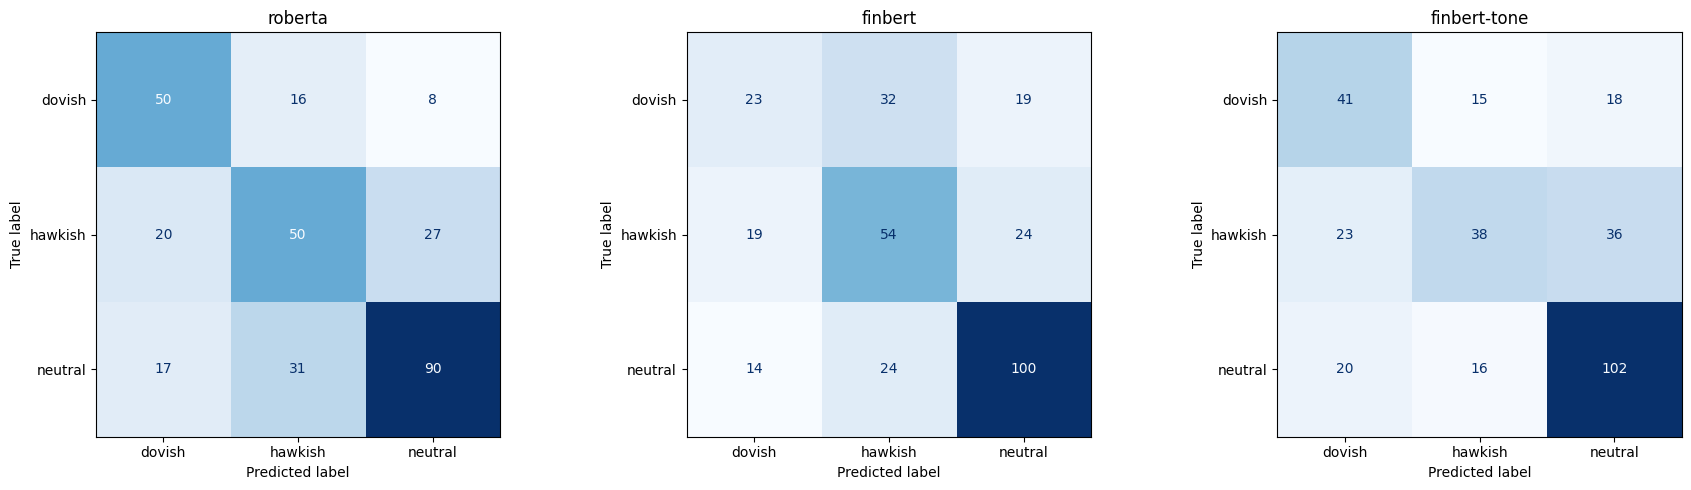

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

# Tokenize the test set once per model (tokenizers differ between roberta and the berts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = [id2label[i] for i in range(num_labels)]  # ['dovish', 'hawkish', 'neutral'] order per your label2id

for ax, (name, ckpt) in zip(axes, MODELS.items()):
    best_dir = f"/kaggle/working/models/{name}/best"

    tokenizer = AutoTokenizer.from_pretrained(best_dir)
    model = AutoModelForSequenceClassification.from_pretrained(best_dir)

    tokenized_test = dataset["test"].map(
        lambda b: tokenizer(b["text"], truncation=True, max_length=256),
        batched=True,
    )

    trainer = Trainer(
        model=model,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
    )

    preds = trainer.predict(tokenized_test)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

    # Per-class F1 printed for each model
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150)
plt.show()

In [ ]:
from huggingface_hub import login
login(token="xxxxxxxxxx")

from transformers import AutoTokenizer, AutoModelForSequenceClassification

HF_USERNAME = "LorenzoAleCon29"   

for name in MODELS:
    best_dir = f"/kaggle/working/models/{name}/best"
    repo_id = f"{HF_USERNAME}/{name}-fomc-hawkish-dovish"

    model = AutoModelForSequenceClassification.from_pretrained(best_dir)
    tokenizer = AutoTokenizer.from_pretrained(best_dir)

    model.push_to_hub(repo_id, private=True)
    tokenizer.push_to_hub(repo_id, private=True)
    print(f"pushed → https://huggingface.co/{repo_id}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

pushed → https://huggingface.co/LorenzoAleCon29/finbert-tone-fomc-hawkish-dovish
